# Análise exploratória dos dados de câncer no Brasil

Dados provenientes do INCA (Instituto Nacional de Câncer) foram carregados para análise. Fonte dos dados: [INCA - Registro Hospitalar de Câncer](https://irhc.inca.gov.br/RHCNet/visualizaTabNetExterno.action) e [Kaggle](https://www.kaggle.com/dfsets/rafatrindade/onco-360?select=raw_inca_registro_hospitalar.parquet).

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pyspark.sql import functions as F

In [0]:
df = spark.read.parquet('/Volumes/workspace/default/cancer_data/raw_inca_registro_hospitalar.parquet')
display(df.limit(10))

TPCASO,SEXO,IDADE,LOCALNAS,RACACOR,INSTRUC,CLIATEN,CLITRAT,HISTFAMC,ALCOOLIS,TABAGISM,ESTADRES,PROCEDEN,ANOPRIDI,ORIENC,EXDIAG,ESTCONJ,ANTRI,DTPRICON,DIAGANT,BASMAIMP,LOCTUDET,LOCTUPRI,TIPOHIST,LATERALI,LOCTUPRO,MAISUMTU,TNM,ESTADIAM,OUTROESTA,PTNM,RZNTR,DTINITRT,PRITRATH,ESTDFIMT,CNES,UFUH,MUUH,OCUPACAO,DTDIAGNO,DTTRIAGE,DATAPRICON,DATAINITRT,DATAOBITO,VALOR_TOT,BASDIAGSP,ESTADIAG
2,2,071,RJ,1,9,10,88,2,1,1,RJ,3304557,2002,9,4,3,9999,2000,1,7,C44,C44.3,8090/3,8,nan,1,999,99,88,888,9,nan,1,8,2269783,RJ,3304557,888,10/03/2002,99/99/9999,02/06/2000,88/88/8888,nan,1,3,null
2,1,000,99,9,9,27,88,9,9,9,99,9999999,2002,9,2,9,2000,2000,9,7,C13,C13.9,8070/3,8,nan,1,999,99,88,888,9,nan,1,8,2269783,RJ,3304557,9999,02/01/2002,15/11/2000,11/12/2000,88/88/8888,nan,1,3,null
1,2,049,RJ,1,9,20,20,2,1,1,RJ,3304557,2002,9,2,2,9999,2000,1,7,C49,C49.2,8000/3,8,nan,1,888,88,88,888,8,2002,2,9,2269783,RJ,3304557,799,21/07/2002,99/99/9999,31/05/2000,21/06/2002,nan,1,3,null
1,1,066,ES,1,9,32,32,1,9,3,RJ,3300456,2002,9,1,2,9999,2000,1,7,C61,C61.9,8551/3,8,nan,1,999,99,88,999,3,2002,2,8,2269783,RJ,3304557,985,27/05/2002,99/99/9999,06/06/2000,15/04/2002,nan,1,3,null
1,2,060,99,1,9,11,4,1,1,3,RJ,3301702,2002,9,4,3,9999,2000,1,7,C73,C73.9,8340/3,8,nan,1,999,99,88,999,8,2002,2,9,2269783,RJ,3304557,9999,21/08/2002,99/99/9999,15/10/2000,09/07/2002,nan,1,3,null
2,1,046,RJ,9,9,9,88,9,3,1,RJ,3304557,2002,1,2,2,2000,2000,1,2,C22,C22.0,8170/3,8,nan,1,999,99,88,888,9,nan,1,8,2269783,RJ,3304557,999,08/05/2002,12/12/2000,12/12/2000,88/88/8888,07/05/2002,1,2,null
2,1,080,MG,1,9,29,88,2,1,3,RJ,3303500,2002,9,4,2,2000,2000,1,5,C34,C34.3,8140/3,2,nan,2,999,99,88,888,3,nan,1,8,2269783,RJ,3304557,621,11/03/2002,15/11/2000,05/12/2000,88/88/8888,31/05/2002,1,3,null
1,2,047,RJ,2,9,4,4,1,1,1,RJ,3304557,2002,9,4,1,9999,2000,1,7,C73,C73.9,8290/3,8,nan,1,999,99,88,999,7,2002,2,8,2269783,RJ,3304557,888,16/10/2002,99/99/9999,15/12/2000,19/09/2002,nan,1,3,null
1,2,058,99,4,9,15,15,1,9,9,RJ,3304557,2003,9,4,3,9999,2000,1,5,C53,C53.9,8010/3,8,.,1,999,99,88,999,8,2004,22,9,2269783,RJ,3304557,540,14/10/2003,99/99/9999,27/09/2000,15/02/2004,/ /,1,3,null
2,1,055,RJ,1,9,10,88,2,9,3,RJ,3304557,2003,9,4,9,9999,2000,1,7,C44,C44.0,8070/3,8,.,1,999,99,88,888,9,nan,1,8,2269783,RJ,3304557,951,20/05/2003,99/99/9999,12/12/2000,88/88/8888,/ /,1,3,null


In [0]:
mapeamento_colunas = {
    "ALCOOLIS": "historico_alcoolismo",
    "ANOPRIDI": "data_diagnostico",
    "ANTRI": "ano_triagem",
    "BASMAIMP": "base_diagnostico_mais_importante",
    "BASDIAGSP": "base_diagnostico_microscopica",
    "CLIATEN": "clinica_primeiro_atendimento",
    "CLITRAT": "clinica_inicio_tratamento",
    "CNES": "codigo_cnes_hospital",
    "DATAINITRT": "data_inicio_tratamento_hospital",
    "DATAOBITO": "data_obito",
    "DATAPRICON": "data_primeira_consulta",
    "DIAGANT": "diagnostico_tratamento_anteriores",
    "DTDIAGNO": "data_primeiro_diagnostico",
    "DTINITRT": "ano_inicio_tratamento_hospital",
    "DTPRICON": "ano_primeira_consulta",
    "DTTRIAGE": "data_triagem",
    "ESTADIAG": "estadiamento_clinico_grupo",
    "ESTADIAM": "estadiamento_clinico_tnm",
    "ESTADRES": "uf_procedencia",
    "ESTCONJ": "estado_conjugal",
    "ESTDFIMT": "estado_doenca_fim_tratamento",
    "EXDIAG": "exames_relevantes_diagnostico",
    "HISTFAMC": "historico_familiar_cancer",
    "IDADE": "idade",
    "INSTRUC": "escolaridade",
    "LATERALI": "lateralidade_tumor",
    "LOCALNAS": "local_nascimento",
    "LOCTUDET": "localizacao_primaria_3_digitos",
    "LOCTUPRI": "localizacao_primaria_detalhada",
    "LOCTUPRO": "localizacao_provavel_primaria",
    "MAISUMTU": "mais_de_um_tumor_primario",
    "MUUH": "municipio_hospital",
    "OCUPACAO": "ocupacao_principal",
    "ORIENC": "origem_encaminhamento",
    "OUTROESTA": "outros_estadiamentos_clinicos",
    "PRITRATH": "primeiro_tratamento_hospital",
    "PROCEDEN": "codigo_municipio_residencia",
    "PTNM": "ptnm",
    "RACACOR": "raca_cor",
    "RZNTR": "razao_nao_tratamento_hospital",
    "SEXO": "sexo",
    "TABAGISM": "historico_tabagismo",
    "TIPOHIST": "tipo_histologico_tumor",
    "TNM": "tnm",
    "TPCASO": "tipo_caso",
    "UFUH": "uf_hospital",
    "VALOR_TOT": "text"
}

for nome_original, novo_nome in mapeamento_colunas.items():
    if nome_original in df.columns:
        df = df.withColumnRenamed(nome_original, novo_nome)

df.printSchema()

root
 |-- tipo_caso: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- idade: string (nullable = true)
 |-- local_nascimento: string (nullable = true)
 |-- raca_cor: string (nullable = true)
 |-- escolaridade: string (nullable = true)
 |-- clinica_primeiro_atendimento: string (nullable = true)
 |-- clinica_inicio_tratamento: string (nullable = true)
 |-- historico_familiar_cancer: string (nullable = true)
 |-- historico_alcoolismo: string (nullable = true)
 |-- historico_tabagismo: string (nullable = true)
 |-- uf_procedencia: string (nullable = true)
 |-- codigo_municipio_residencia: string (nullable = true)
 |-- data_diagnostico: string (nullable = true)
 |-- origem_encaminhamento: string (nullable = true)
 |-- exames_relevantes_diagnostico: string (nullable = true)
 |-- estado_conjugal: string (nullable = true)
 |-- ano_triagem: string (nullable = true)
 |-- ano_primeira_consulta: string (nullable = true)
 |-- diagnostico_tratamento_anteriores: string (nullable = tru

#### Colunas deletadas

- text: todos tem o mesmo valor
- data_triagem: irrelevante em comparação com outras datas e tem muitos valores nan
- municipio_hospital: decidimos deixar apenas a UF
- codigo_cnes_hospital: como dados do hospital deixamos apenas a UF
- ano_inicio_tratamento_hospital: ja tem outra feature semelhante
- localizacao_provavel_primaria: 99% de valores nulos
- lateralidade_tumor: como n temos a localização do tumor (loctupro) acreditamos que essa feature n agrega valor
- ano_primeira_consulta: ja tem uma feature com a data completa, essa é só o ano e além disso tem mais valores nan
- ano_triagem: ja tem uma feature com a data completa, essa é só o ano e além disso tem mais valores nan
- estado_conjugal: irrelevante para o modelo
- codigo_municipio_residencia: acreditamos que a localização do hospital já cobre esse aspecto
- clinica_inicio_tratamento: irrelevante, pouco contato com o paciente, hospital tende a ser mais importante
- clinica_primeiro_atendimento: irrelevante, pouco contato com o paciente, hospital tende a ser mais importante
- local_nascimento: acreditamos ser mais importante a localização do hospital do que a do nascimento da pessoa, visto que ela pode ter se mudado e nem ter mais relação com a cidade natal
- estadiamento_clinico_grupo: muitos valores nan
- estadiamento_clinico_tnm: muitos valores nan
- data_diagnostico: tem data_primeiro_diagnostico que é mais completa
- outros_estadiamentos_clinicos: falta de informação
- localizacao_primaria_3_digitos: localizacao_primaria_detalhada tem a mesma informação e de forma mais completa

In [0]:
colunas_para_remover = ['text', 'data_triagem', 'municipio_hospital', 'codigo_cnes_hospital', 'ano_inicio_tratamento_hospital', 'localizacao_provavel_primaria', 'lateralidade_tumor', 'ano_primeira_consulta', 'ano_triagem', 'estado_conjugal', 'codigo_municipio_residencia', 'clinica_inicio_tratamento', 'clinica_primeiro_atendimento', 'local_nascimento', 'estadiamento_clinico_grupo', 'estadiamento_clinico_tnm', 'data_diagnostico', 'outros_estadiamentos_clinicos', 'localizacao_primaria_3_digitos']

df = df.drop(*colunas_para_remover)

In [0]:
df = df.replace('nan', None)

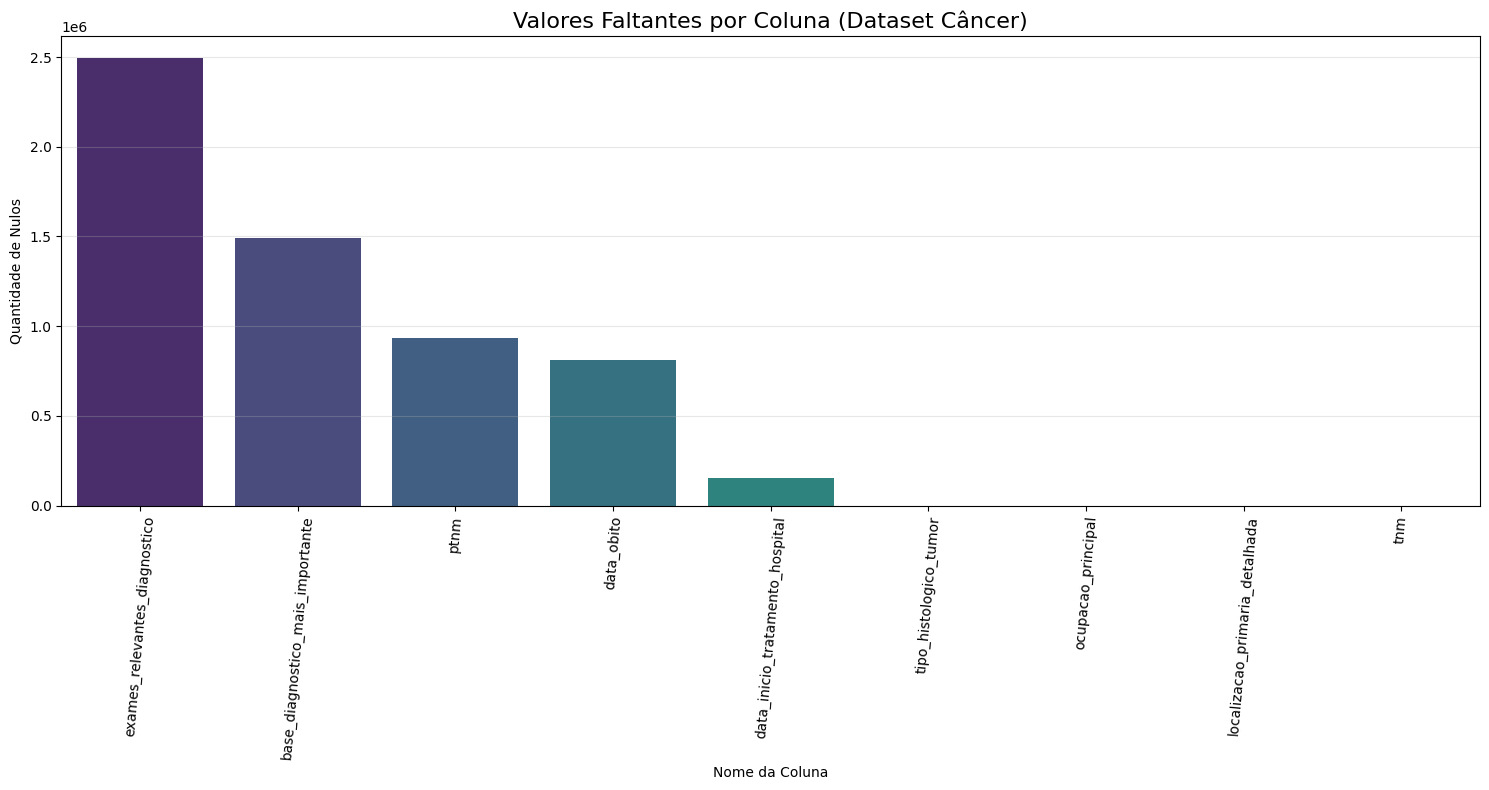

In [0]:
# 1. Calculando nulos para todas as colunas
# Usamos .isNull() para nulos reais e comparamos com 'nan' (string) 
null_counts = df.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c) == 'nan') | (F.col(c) == ''), c)).alias(c)
    for c in df.columns
]).collect()[0].asDict()

# 2. Convertendo para Pandas para o Gráfico
df_missing = pd.DataFrame(list(null_counts.items()), columns=['Coluna', 'Total_Nulos'])

# 3. Filtrando apenas as que possuem nulos e ordenando
df_missing = df_missing[df_missing['Total_Nulos'] > 0].sort_values(by='Total_Nulos', ascending=False)

# 4. Plotando
if not df_missing.empty:
    plt.figure(figsize=(15, 8))
    sns.barplot(data=df_missing, x='Coluna', y='Total_Nulos', palette='viridis')
    
    plt.xticks(rotation=85) # Rotação maior pois você tem muitos nomes de colunas
    plt.title('Valores Faltantes por Coluna (Dataset Câncer)', fontsize=16)
    plt.ylabel('Quantidade de Nulos')
    plt.xlabel('Nome da Coluna')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor nulo ou 'nan' encontrado!")

In [0]:
print("Total de linhas antes de remover os nulos: " + str(df.count()))
df = df.dropna(subset=[col for col in df.columns if col != 'data_obito'])
print("Total de linhas depois de remover os nulos: " + str(df.count()))

Total de linhas antes de remover os nulos: 5399686
Total de linhas depois de remover os nulos: 2905795


In [0]:
# Salvar dados
df.write.mode("overwrite").option("overwriteSchema", "True").saveAsTable("after_nan_table")

## Feature manipuation

In [0]:
df = spark.table("after_nan_table")

In [0]:
cols_left = df.columns

def clean_columns(*args):
    if args is not None:
        for col in args:
            cols_left.remove(col)
    display(cols_left)

    if len(cols_left) == 0:
        print("Não há mais colunas para limpar!")
    return

clean_columns()

_1
tipo_caso
sexo
idade
raca_cor
escolaridade
historico_familiar_cancer
historico_alcoolismo
historico_tabagismo
uf_procedencia
origem_encaminhamento


### Dates

In [0]:
# Transformar datas em formato de data spark
date_cols = [
    'data_primeiro_diagnostico', 
    'data_inicio_tratamento_hospital', 
    'data_obito', 
    'data_primeira_consulta'
]

df = df.withColumns({
    c: F.expr(f"try_to_date({c}, 'dd/MM/yyyy')") 
    for c in date_cols if c in df.columns
})

display(df.limit(3))

tipo_caso,sexo,idade,raca_cor,escolaridade,historico_familiar_cancer,historico_alcoolismo,historico_tabagismo,uf_procedencia,origem_encaminhamento,exames_relevantes_diagnostico,diagnostico_tratamento_anteriores,base_diagnostico_mais_importante,localizacao_primaria_detalhada,tipo_histologico_tumor,mais_de_um_tumor_primario,tnm,ptnm,razao_nao_tratamento_hospital,primeiro_tratamento_hospital,estado_doenca_fim_tratamento,uf_hospital,ocupacao_principal,data_primeiro_diagnostico,data_primeira_consulta,data_inicio_tratamento_hospital,data_obito,base_diagnostico_microscopica
2,2,071,1,9,2,1,1,RJ,9,4,1,7,C44.3,8090/3,1,999,888,9,1,8,RJ,888,2002-03-10,2000-06-02,null,null,3
2,1,000,9,9,9,9,9,99,9,2,9,7,C13.9,8070/3,1,999,888,9,1,8,RJ,9999,2002-01-02,2000-12-11,null,null,3
1,2,049,1,9,2,1,1,RJ,9,2,1,7,C49.2,8000/3,1,888,888,8,2,9,RJ,799,2002-07-21,2000-05-31,2002-06-21,null,3


In [0]:
# Análise das datas
# Criamos uma lista de expressões para processar tudo em uma única passagem pelos dados
agg_exprs = []
for c in date_cols:
    if c in df.columns:
        agg_exprs.extend([
            F.min(c).alias(f"{c}_min"),
            F.max(c).alias(f"{c}_max"),
            F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_nan")
        ])

# Executa a agregação e traz o resultado
stats = df.select(agg_exprs).collect()[0]

for c in date_cols:
    if c in df.columns:
        print(f"\n{c}:")
        print(f"  Min: {stats[f'{c}_min']}")
        print(f"  Max: {stats[f'{c}_max']}")
        print(f"  NaN: {stats[f'{c}_nan']}")


data_primeiro_diagnostico:
  Min: 1921-09-22
  Max: 2025-01-02
  NaN: 79524

data_inicio_tratamento_hospital:
  Min: 1954-10-28
  Max: 2025-02-05
  NaN: 471607

data_obito:
  Min: 2000-01-04
  Max: 4004-12-15
  NaN: 2343629

data_primeira_consulta:
  Min: 2000-01-01
  Max: 2023-12-31
  NaN: 0


In [0]:
min_date, max_date = '1900-01-01', '2023-12-31'

# 1. Condições de Range de Data
range_cond = (
    (F.col('data_primeiro_diagnostico').between(min_date, max_date)) &
    (F.col('data_inicio_tratamento_hospital').between(min_date, max_date) | F.col('data_inicio_tratamento_hospital').isNull()) &
    (F.col('data_obito').between(min_date, max_date) | F.col('data_obito').isNull())
)

# 2. Condições de Inconsistência Lógica (Invertidas para manter o que é válido)
# Regra: Diagnóstico <= Tratamento <= Óbito
logic_cond = (
    ((F.col('data_inicio_tratamento_hospital') >= F.col('data_primeiro_diagnostico')) | F.col('data_inicio_tratamento_hospital').isNull()) &
    ((F.col('data_obito') >= F.col('data_primeiro_diagnostico')) | F.col('data_obito').isNull()) &
    ((F.col('data_obito') >= F.col('data_inicio_tratamento_hospital')) | F.col('data_obito').isNull() | F.col('data_inicio_tratamento_hospital').isNull())
)

# Aplica tudo em um único scan
df = df.filter(range_cond & logic_cond)

In [0]:
consulta_antes = df.filter(
    (F.col('data_primeira_consulta').isNotNull()) & 
    (F.col('data_primeiro_diagnostico').isNotNull()) & 
    (F.col('data_primeira_consulta') < F.col('data_primeiro_diagnostico'))
).count()

consulta_depois = df.filter(
    (F.col('data_primeira_consulta').isNotNull()) & 
    (F.col('data_primeiro_diagnostico').isNotNull()) & 
    (F.col('data_primeira_consulta') >= F.col('data_primeiro_diagnostico'))
).count()

print(f"Primeira consulta antes do diagnóstico: {consulta_antes}")
print(f"Primeira consulta depois ou no mesmo dia do diagnóstico: {consulta_depois}")

Primeira consulta antes do diagnóstico: 791893
Primeira consulta depois ou no mesmo dia do diagnóstico: 1747958


In [0]:
# Excluindo datas null, exceto para data_obito em que null pode significar que a pessoa esta viva (ent precisamos dessa info)
df = df.dropna(subset=['data_primeiro_diagnostico', 'data_inicio_tratamento_hospital', 'data_primeira_consulta'])
display(df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]))

tipo_caso,sexo,idade,raca_cor,escolaridade,historico_familiar_cancer,historico_alcoolismo,historico_tabagismo,uf_procedencia,origem_encaminhamento,exames_relevantes_diagnostico,diagnostico_tratamento_anteriores,base_diagnostico_mais_importante,localizacao_primaria_detalhada,tipo_histologico_tumor,mais_de_um_tumor_primario,tnm,ptnm,razao_nao_tratamento_hospital,primeiro_tratamento_hospital,estado_doenca_fim_tratamento,uf_hospital,ocupacao_principal,data_primeiro_diagnostico,data_primeira_consulta,data_inicio_tratamento_hospital,data_obito,base_diagnostico_microscopica
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1711477,0


In [0]:
clean_columns(
    'data_primeiro_diagnostico',
    'data_inicio_tratamento_hospital', 
    'data_obito', 
    'data_primeira_consulta'
)

_1
tipo_caso
sexo
idade
raca_cor
escolaridade
historico_familiar_cancer
historico_alcoolismo
historico_tabagismo
uf_procedencia
origem_encaminhamento


### Idade

In [0]:
# Validação coluna 'idade'
df = df.withColumn('idade', F.expr("try_cast(idade as int)"))

df = df.filter(
    (F.col('idade').isNotNull()) & 
    (F.col('idade') >= 0) & 
    (F.col('idade') <= 100)
)

In [0]:
clean_columns('idade')

_1
tipo_caso
sexo
raca_cor
escolaridade
historico_familiar_cancer
historico_alcoolismo
historico_tabagismo
uf_procedencia
origem_encaminhamento
exames_relevantes_diagnostico


### TNM e PTNM


TNM: 928320

PTNM: 560987

**TNM and PTNM: 389_434**

In [0]:
def extrair_tnm_seguro(df, col_name):
    for i, letra in enumerate(["t", "n", "m"], start=1):
        col_final = f"{letra}_{col_name}"
        df = df.withColumn(col_final, 
            F.when(F.substring(F.col(col_name), i, 1) == "X", -1)
             .otherwise(F.expr(f"try_cast(substring({col_name}, {i}, 1) as int)"))
        )
    return df

# 1. Aplicar a extração (X vira -1, letras viram NULL)
df = extrair_tnm_seguro(df, "tnm")
df = extrair_tnm_seguro(df, "ptnm")

df = df.filter(
    (F.col("t_tnm").between(-1, 4)) & 
    (F.col("n_tnm").between(-1, 3)) & 
    (F.col("m_tnm").between(-1, 1)) &
    (F.col("t_ptnm").between(-1, 4)) & 
    (F.col("n_ptnm").between(-1, 3)) & 
    (F.col("m_ptnm").between(-1, 1))
)

df = df.drop("tnm", "ptnm")

In [0]:
clean_columns("tnm", "ptnm")
df.count()

_1
tipo_caso
sexo
raca_cor
escolaridade
historico_familiar_cancer
historico_alcoolismo
historico_tabagismo
uf_procedencia
origem_encaminhamento
exames_relevantes_diagnostico


389434

### Outras colunas

In [0]:
# Excluindo linhas que contenham alguma feature com valor fora do dominio valido (https://raw.githubusercontent.com/rafa-trindade/oncoped-360/main/docs/dicionario_inca_registro_hospitalar.pdf)
validos = {
    "tipo_caso": {"1", "2"},
    "sexo": {"1", "2"},
    "raca_cor": {"1", "2", "3", "4", "5"},
    "escolaridade": {"1", "2", "3", "4", "5", "6"},
    "historico_familiar_cancer": {"1", "2"},
    "historico_alcoolismo": {"1", "2", "3", "4", "8"},
    "historico_tabagismo": {"1", "2", "3", "4", "8"},
    "origem_encaminhamento": {"1", "2", "3", "8"},
    "exames_relevantes_diagnostico": {"1", "2", "3", "4", "5", "8"},
    "diagnostico_tratamento_anteriores": {"1", "2", "3", "4"},
    "base_diagnostico_mais_importante": {"1", "2", "3", "4", "5", "6", "7"},
    "mais_de_um_tumor_primario": {"1", "2", "3"},
    "razao_nao_tratamento_hospital": {"1", "2", "3", "4", "5", "6", "7", "8"},
    "primeiro_tratamento_hospital": {"1", "2", "3", "4", "5", "6", "7", "8"},
    "estado_doenca_fim_tratamento": {"1", "2", "3", "4", "5", "6", "8"},
    "base_diagnostico_microscopica": {"1", "2", "3"},
}

ufs_validas = {
    "AC","AL","AP","AM","BA","CE","DF","ES","GO","MA","MT","MS",
    "MG","PA","PB","PR","PE","PI","RJ","RN","RS","RO","RR","SC",
    "SP","SE","TO"
}

# 1. Filtros de Categorias Fixas
for col, valores in validos.items():
    if col in df.columns:
        df = df.filter(F.col(col).isin(list(valores)))

# 2. Filtros de UFs
for col in ["uf_procedencia", "uf_hospital"]:
    if col in df.columns:
        df = df.filter(F.col(col).isin(list(ufs_validas)))

# 3. Filtros com Regex (rlike)
if "ocupacao_principal" in df.columns:
    # O regex [1-9]\d* garante que comece com 1-9 (evita 0, negativos ou vazios)
    df = df.filter(F.col("ocupacao_principal").rlike("^[1-9]\d*$"))

if "tipo_histologico_tumor" in df.columns:
    df = df.filter(F.col("tipo_histologico_tumor").rlike("^(8|9)\d{3}/[012369]$"))

if "localizacao_primaria_detalhada" in df.columns:
    df = df.filter(F.col("localizacao_primaria_detalhada").rlike("^C(0[0-9]|[1-7][0-9]|80)\.[0-9]$"))

In [0]:
clean_columns(
    *tuple(validos.keys()), 
    "uf_procedencia", 
    "uf_hospital", 
    "ocupacao_principal", 
)

_1
localizacao_primaria_detalhada
tipo_histologico_tumor


### Localizacao_primaria_detalhada, tipo_histologico_tumor

In [0]:
df_transformado = df.withColumn(
    # 1. Parte principal da localização (ex: 44)
    # Pega os dígitos que vêm logo após o 'C'
    "cat_localizacao_primaria", F.regexp_extract(F.col("localizacao_primaria_detalhada"), r"C(\d+)", 1).cast("int")
).withColumn(
    # 2. Subcategoria da localização (ex: 7)
    # Pega os dígitos que vêm após o ponto '.'
    "subcat_localizacao_primaria", F.regexp_extract(F.col("localizacao_primaria_detalhada"), r"\.(\d+)", 1).cast("int")
).withColumn(
    # 3. Comportamento (ex: 2)
    # Pega o dígito depois da barra '/'
    "comportamento_histologico_tumor", F.regexp_extract(F.col("tipo_histologico_tumor"), r"/(\d+)", 1).cast("int")
).withColumn(
    # 4. Tipo Histológico (ex: 8720)
    # Pega os dígitos antes da barra '/'
    "tipo_histologico_tumor", F.regexp_extract(F.col("tipo_histologico_tumor"), r"(\d+)/", 1).cast("int")
).drop("localizacao_primaria_detalhada")

In [0]:
clean_columns(
    "tipo_histologico_tumor", 
    "localizacao_primaria_detalhada"
)

[]

Não há mais colunas para limpar!


In [0]:
display(df.count())
display(df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]))

73541

tipo_caso,sexo,idade,raca_cor,escolaridade,historico_familiar_cancer,historico_alcoolismo,historico_tabagismo,uf_procedencia,origem_encaminhamento,exames_relevantes_diagnostico,diagnostico_tratamento_anteriores,base_diagnostico_mais_importante,localizacao_primaria_detalhada,tipo_histologico_tumor,mais_de_um_tumor_primario,razao_nao_tratamento_hospital,primeiro_tratamento_hospital,estado_doenca_fim_tratamento,uf_hospital,ocupacao_principal,data_primeiro_diagnostico,data_primeira_consulta,data_inicio_tratamento_hospital,data_obito,base_diagnostico_microscopica,t_tnm,n_tnm,m_tnm,t_ptnm,n_ptnm,m_ptnm
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,64380,0,0,0,0,0,0,0


In [0]:
df.write.mode("overwrite").option("overwriteSchema", "True").saveAsTable("after_coerencia_dados")

## Criando novas features

- separar idade em faixas etárias?
- separar datas em anos (ou em periodos?), manter meses e dias?

In [0]:
df = spark.table("after_coerencia_dados")

In [0]:
# 1. Criar status_vital: 0 para mortos (estado '6' ou data_obito preenchida), 1 para vivos
df = df.withColumn(
    "status_vital",
    F.when(
        (F.col("estado_doenca_fim_tratamento") == "6") | (F.col("data_obito").isNotNull()), 
        0
    ).otherwise(1)
)

# 2. Criar tempo_total_doenca, tempo_ate_consulta e tempo_ate_tratamento (em dias)
df = df.withColumn(
    "tempo_total_doenca",
    F.when(
        F.col("status_vital") == 1,
        F.datediff(F.lit("2023-12-31"), F.col("data_primeiro_diagnostico"))
    ).when(
        F.col("data_obito").isNull(),
        F.datediff(F.col("data_inicio_tratamento_hospital"), F.col("data_primeiro_diagnostico"))
    ).otherwise(
        F.datediff(F.col("data_obito"), F.col("data_primeiro_diagnostico"))
    )
)

df = df.withColumn(
    "tempo_ate_consulta", 
    F.datediff(F.col("data_primeira_consulta"), F.col("data_primeiro_diagnostico"))
)

df = df.withColumn(
    "tempo_ate_tratamento",
    F.datediff(F.col("data_inicio_tratamento_hospital"), F.col("data_primeiro_diagnostico"))
)

df = df.withColumn(
    "tempo_ate_obito", 
    F.datediff(F.col("data_obito"), F.col("data_primeiro_diagnostico"))
)

In [0]:
print(df.filter(F.col("tempo_ate_consulta") < 0).count())
print(df.filter(F.col("tempo_ate_consulta") > 0).count())
print(df.filter(F.col("tempo_ate_consulta") == 0).count())

19148
51489
2904


In [0]:
df = df.drop(
    "estado_doenca_fim_tratamento", # TBD
    "data_primeiro_diagnostico", 
    "data_inicio_tratamento_hospital", 
    "data_primeira_consulta", 
    "data_obito"
)

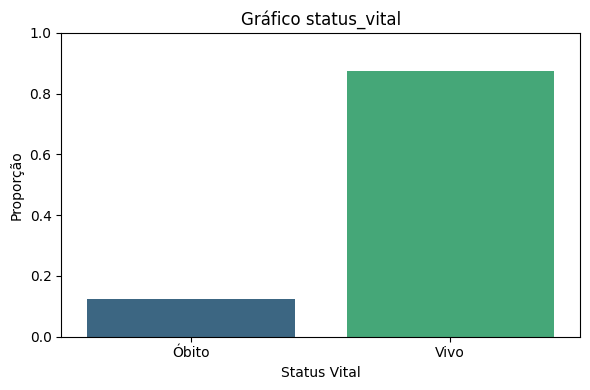

In [0]:
status_counts = (
    df.groupBy('status_vital')
      .count()
      .withColumn('proporcao', F.col('count') / df.count())
      .orderBy('status_vital')
      .toPandas()
)
plt.figure(figsize=(6, 4))
sns.barplot(x=['Óbito' if i == 0 else 'Vivo' for i in status_counts['status_vital']], y=status_counts['proporcao'], palette='viridis')
plt.title('Gráfico status_vital')
plt.ylabel('Proporção')
plt.xlabel('Status Vital')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Encode

Fazer one-hot encoding das variáveis categóricas selecionadas, como tnm, loctupri, sexo, etc

Para um modelo de rsf, os códigos de CID-O não devem ser usados como valores numéricos brutos, pois isso introduz uma ordem artificial sem significado clínico; em vez disso:

- tratar a variável como categórica, preferencialmente usando a localizacao_primaria_detalhada (CID-O, 4 dígitos) por ser mais informativa. Caso o número de observações seja limitado, usar localizacao_primaria_3_digitos (CID-O, 3 dígitos)
- agrupar categorias raras (por exemplo, localizações com baixa frequência) em uma classe “Outros”
- aplicar one-hot encoding 

In [0]:
#TODO : coisas acima para a feature de CID-O

In [0]:
#TODO: fazer encoding de todas outras variaveis necessarias

## Gráficos

In [0]:
map_sexo = {
    '1': 'Masculino',
    '2': 'Feminino'
}

map_tabagismo = {
    '1': 'Nunca',
    '2': 'Ex-consumidor',
    '3': 'Sim',
    '4': 'Não avaliado',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_alcool = map_tabagismo.copy()

map_racacor = {
    '1': 'Branca',
    '2': 'Preta',
    '3': 'Amarela',
    '4': 'Parda',
    '5': 'Indígena',
    '9': 'Sem informação'
}

map_estdfimt = {
    '1': 'Remissão completa',
    '2': 'Remissão parcial',
    '3': 'Doença estável',
    '4': 'Progressão',
    '5': 'Suporte terapêutico',
    '6': 'Óbito',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_pritrath = {
    '1': 'Nenhum',
    '2': 'Cirurgia',
    '3': 'Radioterapia',
    '4': 'Quimioterapia',
    '5': 'Hormonioterapia',
    '6': 'Transplante de medula óssea',
    '7': 'Imunoterapia',
    '8': 'Outros',
    '9': 'Sem informação'
}

map_base_diagnostico_mais_importante = {
    '1': 'Clínica',
    '2': 'Pesquisa clínica',
    '3': 'Exame por imagem',
    '4': 'Marcadores tumorais',
    '5': 'Citologia',
    '6': 'Histologia da metástase',
    '7': 'Histologia do tumor primário',
    '9': 'Sem informação'
}

map_exdiag = {
    '1': 'Exame clínico / Patologia clínica',
    '2': 'Exames por imagem',
    '3': 'Endoscopia / Cirurgia exploradora',
    '4': 'Anatomia patológica',
    '5': 'Marcadores tumorais',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_orienc = {
    '1': 'SUS',
    '2': 'Não SUS',
    '3': 'Conta própria',
    '8': 'Não se aplica',
    '9': 'Sem informação'
}

map_tp_caso = {
    '1': 'Analítico',
    '2': 'Não analítico',
}

map_status_vital = {
    0: 'Óbito',
    1: 'Vivo'
}

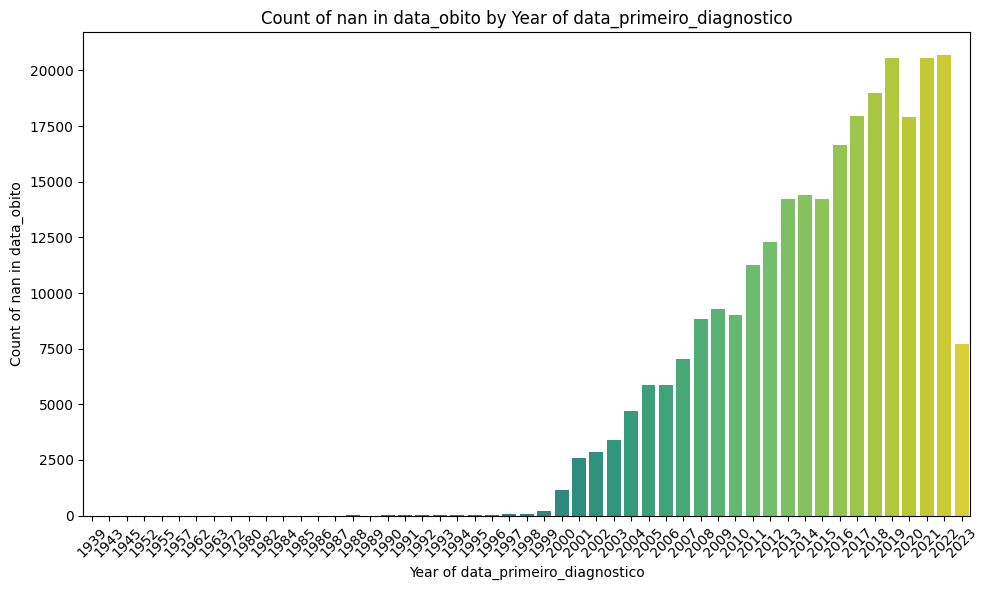

In [0]:
from pyspark.sql.functions import year

df_year = df.withColumn('data_primeiro_diagnostico_Year', year('data_primeiro_diagnostico'))
obito_counts = df_year.filter(df_year['data_obito'].isNull()) \
    .groupBy('data_primeiro_diagnostico_Year') \
    .count() \
    .orderBy('data_primeiro_diagnostico_Year')

obito_counts_pd = obito_counts.toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x=obito_counts_pd['data_primeiro_diagnostico_Year'], y=obito_counts_pd['count'], palette='viridis')
plt.title("Count of nan in data_obito by Year of data_primeiro_diagnostico")
plt.xlabel("Year of data_primeiro_diagnostico")
plt.ylabel("Count of nan in data_obito")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

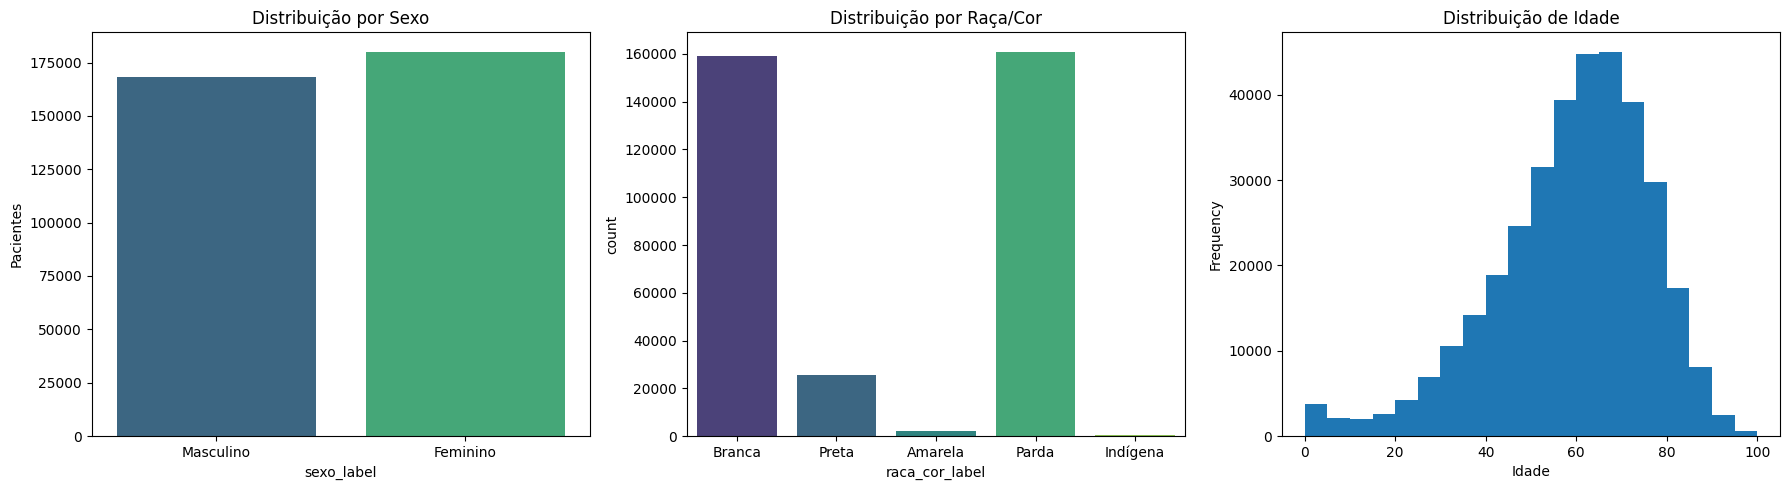

In [0]:
sexo_counts = (
    df.groupBy('sexo')
      .count()
      .orderBy('sexo')
      .toPandas()
)
sexo_counts['sexo_label'] = sexo_counts['sexo'].map(map_sexo)

racacor_counts = (
    df.groupBy('raca_cor')
      .count()
      .orderBy('raca_cor')
      .toPandas()
)
racacor_counts['raca_cor_label'] = racacor_counts['raca_cor'].map(map_racacor)

idade_pd = df.select('idade').where(df['idade'].isNotNull()).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=sexo_counts['sexo_label'], y=sexo_counts['count'], ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição por Sexo')
axes[0].set_ylabel('Pacientes')

sns.barplot(x=racacor_counts['raca_cor_label'], y=racacor_counts['count'], ax=axes[1], palette='viridis')
axes[1].set_title('Distribuição por Raça/Cor')

idade_pd['idade'].plot(kind='hist', bins=20, ax=axes[2])
axes[2].set_title('Distribuição de Idade')
axes[2].set_xlabel('Idade')

plt.tight_layout()
plt.show()

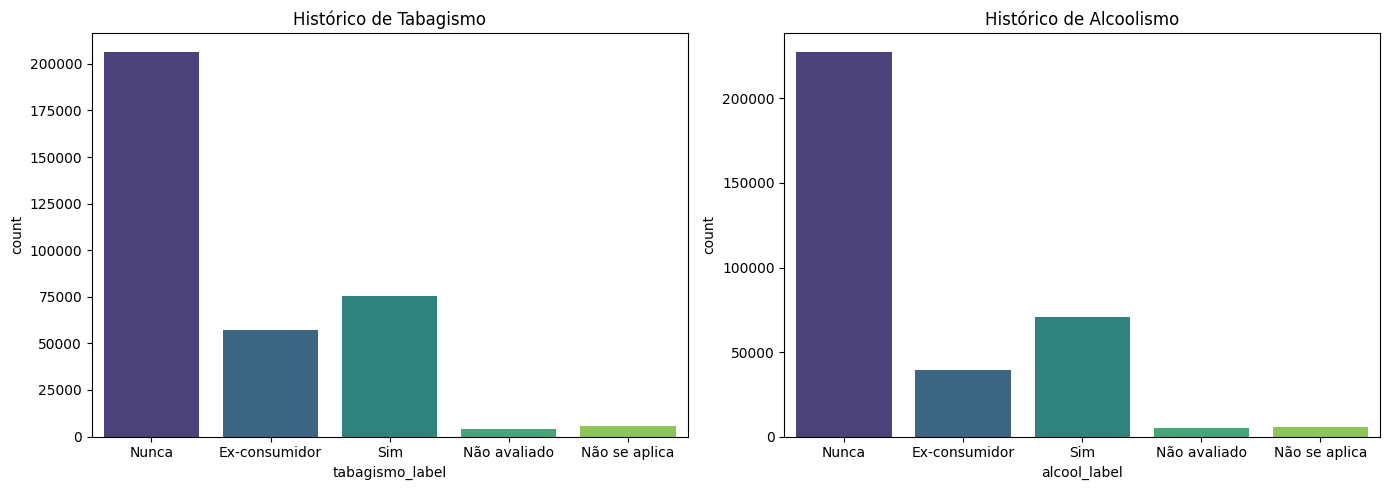

In [0]:
tabagismo_counts = (
    df.groupBy('historico_tabagismo')
      .count()
      .orderBy('historico_tabagismo')
      .toPandas()
)
tabagismo_counts['tabagismo_label'] = tabagismo_counts['historico_tabagismo'].map(map_tabagismo)

alcool_counts = (
    df.groupBy('historico_alcoolismo')
      .count()
      .orderBy('historico_alcoolismo')
      .toPandas()
)
alcool_counts['alcool_label'] = alcool_counts['historico_alcoolismo'].map(map_alcool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=tabagismo_counts['tabagismo_label'], y=tabagismo_counts['count'], ax=axes[0], palette='viridis')
axes[0].set_title('Histórico de Tabagismo')
sns.barplot(x=alcool_counts['alcool_label'], y=alcool_counts['count'], ax=axes[1], palette='viridis')
axes[1].set_title('Histórico de Alcoolismo')
plt.tight_layout()
plt.show()

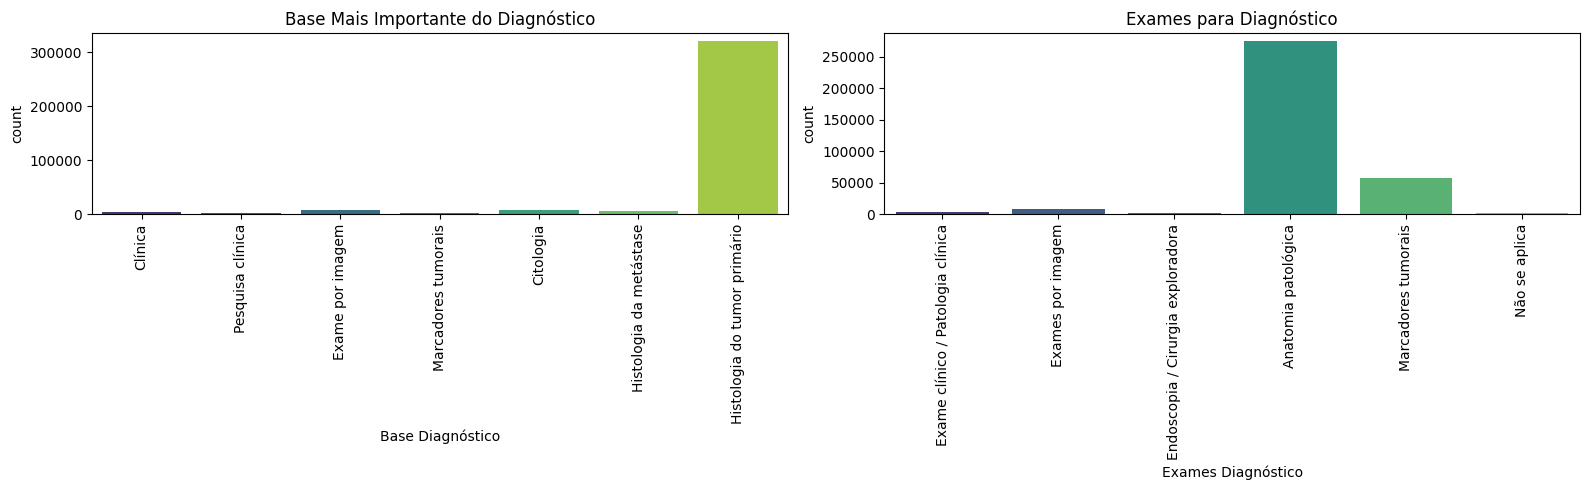

In [0]:
base_diag_counts = (
    df.groupBy('base_diagnostico_mais_importante')
      .count()
      .orderBy('base_diagnostico_mais_importante')
      .toPandas()
)
base_diag_counts['base_diag_label'] = base_diag_counts['base_diagnostico_mais_importante'].map(map_base_diagnostico_mais_importante)

exdiag_counts = (
    df.groupBy('exames_relevantes_diagnostico')
      .count()
      .orderBy('exames_relevantes_diagnostico')
      .toPandas()
)
exdiag_counts['exdiag_label'] = exdiag_counts['exames_relevantes_diagnostico'].map(map_exdiag)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=base_diag_counts['base_diag_label'], y=base_diag_counts['count'], ax=axes[0], palette='viridis')
axes[0].set_title('Base Mais Importante do Diagnóstico')
axes[0].set_xlabel('Base Diagnóstico')
plt.sca(axes[0])
plt.xticks(rotation=90)
sns.barplot(x=exdiag_counts['exdiag_label'], y=exdiag_counts['count'], ax=axes[1], palette='viridis')
axes[1].set_title('Exames para Diagnóstico')
axes[1].set_xlabel('Exames Diagnóstico')
plt.sca(axes[1])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

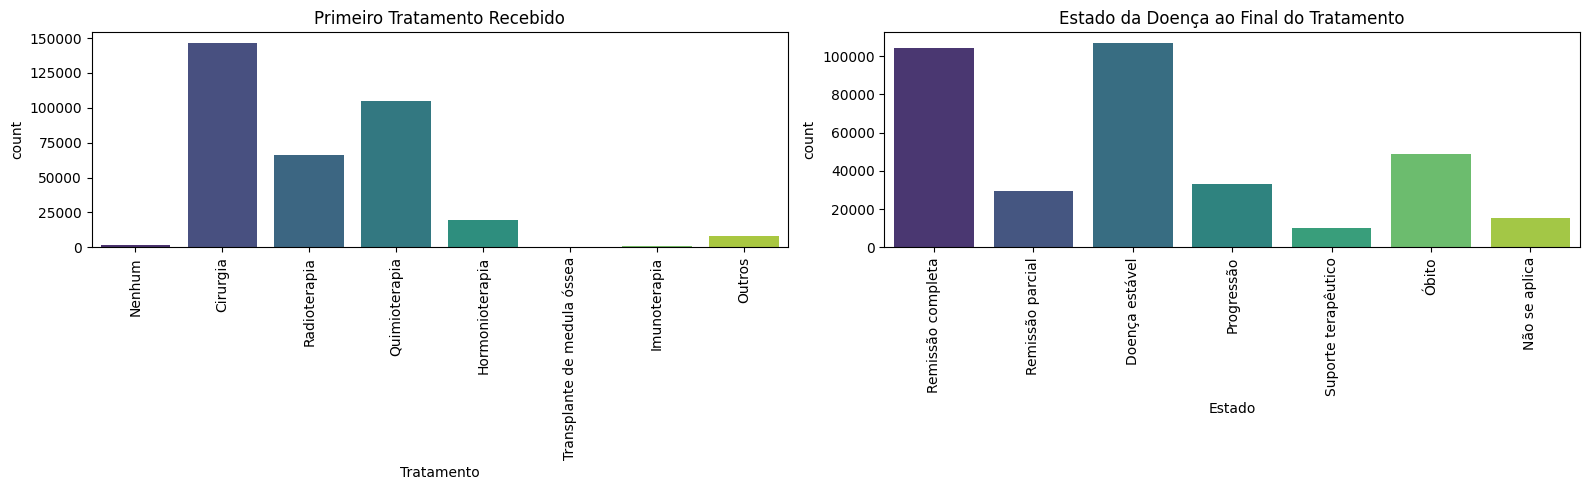

In [0]:
pritrath_counts = (
    df.groupBy('primeiro_tratamento_hospital')
      .count()
      .orderBy('primeiro_tratamento_hospital')
      .toPandas()
)
pritrath_counts['pritrath_label'] = pritrath_counts['primeiro_tratamento_hospital'].map(map_pritrath)

estdfimt_counts = (
    df.groupBy('estado_doenca_fim_tratamento')
      .count()
      .orderBy('estado_doenca_fim_tratamento')
      .toPandas()
)
estdfimt_counts['estdfimt_label'] = estdfimt_counts['estado_doenca_fim_tratamento'].map(map_estdfimt)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=pritrath_counts['pritrath_label'], y=pritrath_counts['count'], ax=axes[0], palette='viridis')
axes[0].set_title('Primeiro Tratamento Recebido')
axes[0].set_xlabel('Tratamento')
plt.sca(axes[0])
plt.xticks(rotation=90)
sns.barplot(x=estdfimt_counts['estdfimt_label'], y=estdfimt_counts['count'], ax=axes[1], palette='viridis')
axes[1].set_title('Estado da Doença ao Final do Tratamento')
axes[1].set_xlabel('Estado')
plt.sca(axes[1])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

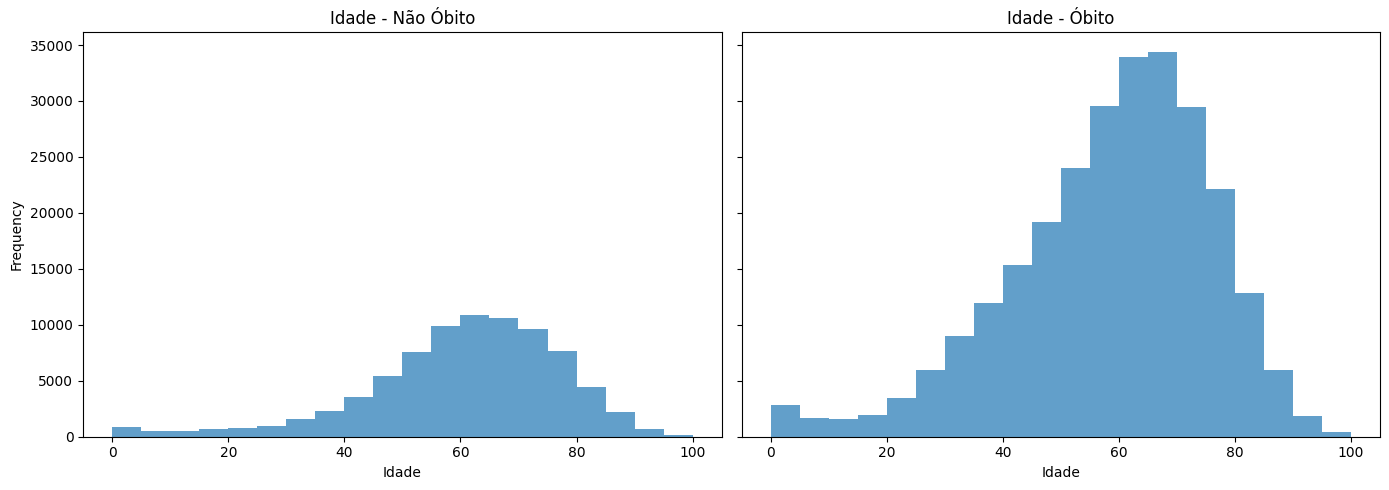

In [0]:
idade_nao_obito_pd = df.filter(df['status_vital'] == 0).select('idade').where(df['idade'].isNotNull()).toPandas()
idade_obito_pd = df.filter(df['status_vital'] == 1).select('idade').where(df['idade'].isNotNull()).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
idade_nao_obito_pd['idade'].plot(kind='hist', bins=20, alpha=0.7, ax=axes[0])
axes[0].set_title('Idade - Não Óbito')
axes[0].set_xlabel('Idade')
idade_obito_pd['idade'].plot(kind='hist', bins=20, alpha=0.7, ax=axes[1])
axes[1].set_title('Idade - Óbito')
axes[1].set_xlabel('Idade')
plt.tight_layout()
plt.show()

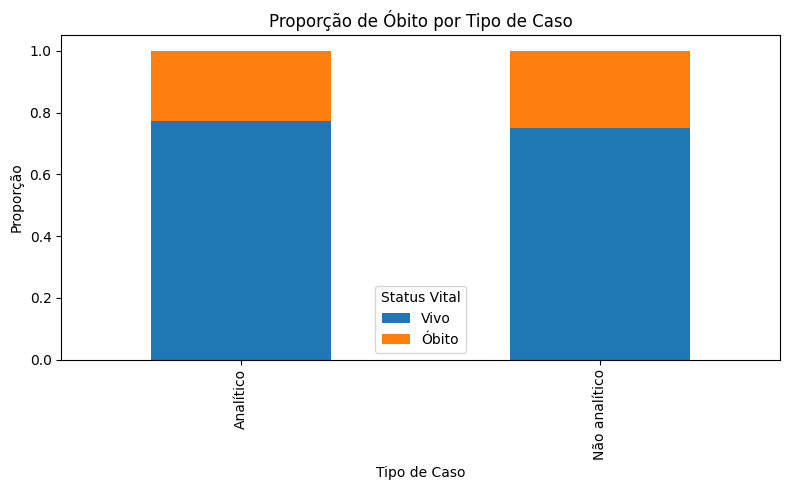

In [0]:
cross_df = df.select('tipo_caso', 'status_vital')
cross_pd = cross_df.toPandas()
cross_pd['tipo_caso_label'] = cross_pd['tipo_caso'].astype(str).str.strip().map(map_tp_caso).fillna('Sem informação')
cross_pd['status_vital_label'] = cross_pd['status_vital'].map(map_status_vital)

cross = pd.crosstab(cross_pd['tipo_caso_label'], cross_pd['status_vital_label'])
cross_prop = cross.div(cross.sum(axis=1), axis=0)
cross_prop.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Proporção de Óbito por Tipo de Caso')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Caso')
plt.legend(title='Status Vital')
plt.tight_layout()
plt.show()